# 🧠 Multimodal Sentiment Analysis
### CNN (Image) + LSTM (Text) → Sentiment Prediction

**Pipeline:**
```
Product Image  ──→  CNN  ──→  Image Feature Vector
                                                     ──→  Fusion Layer → Positive/Neutral/Negative
Product Review ──→  LSTM ──→  Text Feature Vector
```

**Exercises Used:** Feed-Forward Network · CNN · LSTM · RNN (Opinion Mining)

## 📦 Step 1 — Install & Import Libraries

In [ ]:
# Install required libraries
!pip install torch torchvision pandas numpy pillow scikit-learn matplotlib seaborn

In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


## 🗂️ Step 2 — Generate Dataset
We create a synthetic dataset of **150 samples** (50 per class) with:
- **Images**: Synthetic product images (positive=bright/clean, negative=dark/damaged, neutral=plain)
- **Reviews**: Realistic product review text per sentiment

In [2]:
import csv
from PIL import Image, ImageDraw

OUTPUT_DIR = "dataset"
IMAGE_DIR  = os.path.join(OUTPUT_DIR, "images")
os.makedirs(IMAGE_DIR, exist_ok=True)

# ── Review templates ──────────────────────────────────────────────────────────
positive_reviews = [
    "Absolutely love this product! Works perfectly and exceeded my expectations.",
    "Amazing quality, very happy with my purchase. Highly recommend to everyone.",
    "Fantastic item, delivered on time and exactly as described. Will buy again.",
    "Great value for money. The product looks beautiful and functions flawlessly.",
    "Very satisfied with this purchase. Top notch quality and excellent packaging.",
    "Brilliant product! It has made my life so much easier. Totally worth it.",
    "Superb quality and fast delivery. The product is exactly what I needed.",
    "Outstanding product. It works like a charm and looks exactly as pictured.",
    "I am extremely happy with this purchase. The quality is just remarkable.",
    "Excellent product! Great build quality, fast shipping, and perfect condition.",
    "Love it so much! It is durable, stylish, and works beyond my expectations.",
    "Perfect in every way. Beautiful design, top quality and great performance.",
    "This is the best purchase I have made this year. Highly recommended!",
    "Very impressed with the quality. Arrived quickly and packaging was great.",
    "Wonderful experience from start to finish. Product is beautiful and functional.",
]
negative_reviews = [
    "Terrible product. Broke after just two days of use. Complete waste of money.",
    "Very disappointed. The item looks nothing like the pictures shown online.",
    "Awful quality. I expected much better for this price. Would not recommend.",
    "Stopped working within a week. Very poor build quality and cheap materials.",
    "Do not buy this. It is a scam product. Completely useless and overpriced.",
    "Horrible experience. Product arrived damaged and customer service was useless.",
    "Worst purchase ever. Extremely fragile and fell apart immediately after use.",
    "Total waste of money. The product is poorly made and does not work at all.",
    "Very bad quality. It smells strange and looks nothing like the description.",
    "Disgusted with this purchase. It broke on first use and feels very cheap.",
    "Useless product. Does not work as advertised. Returning it immediately.",
    "Really bad. The item came broken and the material feels extremely flimsy.",
    "Disappointed beyond words. Poor quality, bad packaging and slow delivery.",
    "Terrible item. The colors were faded and the product did not function at all.",
    "Would give zero stars if possible. Completely defective and unusable product.",
]
neutral_reviews = [
    "The product is okay. Nothing special but it gets the job done for now.",
    "Average quality. It works as expected but nothing impressive about it.",
    "Decent product. Delivery was fine. Not great but not terrible either.",
    "It is alright. Does what it says but the quality could be better honestly.",
    "Fair enough for the price. Not the best but acceptable for occasional use.",
    "Product is mediocre. It works but I expected a little more from this brand.",
    "So-so product. Packaging was average and quality is just about acceptable.",
    "Neither good nor bad. Works most of the time but has some minor issues.",
    "It is fine. Not as impressive as the reviews suggested but not bad either.",
    "Okay product overall. Met basic requirements but did not wow me at all.",
    "Mixed feelings about this. Some aspects are good but others are lacking.",
    "Just about acceptable. Works for what I need but build quality is average.",
    "Normal product, nothing special. Delivery was on time which was positive.",
    "It does the job but barely. Quality is mediocre and design feels outdated.",
    "Average experience. Product works but feels cheap compared to the price.",
]

SAMPLES_PER_CLASS = 167

review_pools = {
    "positive": positive_reviews,
    "negative": negative_reviews,
    "neutral":  neutral_reviews
}

# ── TEXT GENERATION (with noise) ───────────────────────────────────────────
def generate_text(sentiment):
    base = random.choice(review_pools[sentiment])

    # Add sentiment-rich phrases
    if sentiment == "positive":
        base += random.choice([" loved it", " amazing", " worth it"])
    elif sentiment == "negative":
        base += random.choice([" worst", " waste", " terrible"])
    else:
        base += random.choice([" okay", " average", " fine"])

    return base

# ── IMAGE GENERATOR (IMPROVED) ─────────────────────────────────────────────
def make_image(sentiment, index):
    img = Image.new("RGB", (224,224),
                    color=(random.randint(180,255),
                           random.randint(180,255),
                           random.randint(180,255)))
    draw = ImageDraw.Draw(img)

    r  = random.randint(40,60)
    cx, cy = 112, 100

    # Subtle differences (NOT obvious)
    if sentiment == "positive":
        draw.ellipse([cx-r,cy-r,cx+r,cy+r],
                     fill=(random.randint(100,255),200,random.randint(100,255)))
    elif sentiment == "negative":
        draw.rectangle([cx-r,cy-r,cx+r,cy+r],
                       fill=(200,random.randint(50,150),random.randint(50,150)))
        draw.line([cx-r,cy-r,cx+r,cy+r], fill=(0,0,0), width=2)
    else:
        draw.rectangle([cx-r,cy-r,cx+r,cy+r],
                       fill=(180,180,180))

    # Random brightness (IMPORTANT FIX)
    arr = np.array(img).astype(np.float32)
    brightness = random.uniform(0.6, 1.4)
    arr = np.clip(arr * brightness, 0, 255)

    # Convert to numpy
    arr = np.array(img).astype(np.float32)

    # Apply brightness variation
    brightness = random.uniform(0.6, 1.4)
    arr = np.clip(arr * brightness, 0, 255)

    # Add heavy noise
    noise = np.random.normal(0, 30, arr.shape)
    arr = np.clip(arr + noise, 0, 255)

    # Random blur
    if random.random() < 0.5:
        import cv2
        arr = cv2.GaussianBlur(arr, (7,7), 0)

    # Random occlusion
    if random.random() < 0.3:
        x1, y1 = random.randint(0,150), random.randint(0,150)
        x2, y2 = x1 + random.randint(20,60), y1 + random.randint(20,60)
        arr[y1:y2, x1:x2] = 0

    # 🔥 FINAL FIX (MOST IMPORTANT)
    arr = np.clip(arr, 0, 255).astype(np.uint8)

    # Convert back to image
    img = Image.fromarray(arr)

    # Save
    fname = f"{sentiment}_{index}_{random.randint(0,9999)}.jpg"
    img.save(os.path.join(IMAGE_DIR, fname))

    return fname

# ── DATASET CREATION (WITH CONFLICTS) ──────────────────────────────────────
rows = []
label_map = {"positive": 2, "neutral": 1, "negative": 0}

for sentiment in ["positive", "negative", "neutral"]:
    for i in range(SAMPLES_PER_CLASS):

        # Generate correct image
        fname = make_image(sentiment, i)

        # 20% cross-modal conflict
        if random.random() < 0.4:
            wrong_sentiment = random.choice(
                [s for s in ["positive","neutral","negative"] if s != sentiment]
            )
            review = generate_text(wrong_sentiment)
        else:
            review = generate_text(sentiment)

        rows.append({
            "image_path": f"images/{fname}",
            "review": review,
            "sentiment": sentiment,
            "label": label_map[sentiment]
        })

# Shuffle dataset
random.shuffle(rows)

# Save CSV
df = pd.DataFrame(rows)
df.to_csv(os.path.join(OUTPUT_DIR, "reviews.csv"), index=False)

# ── SUMMARY ───────────────────────────────────────────────────────────────
print("="*55)
print("         MULTIMODAL SENTIMENT ANALYSIS DATASET")
print("="*55)
print(f"Total Samples : {len(df)} (~500)")
print("\nClass Distribution:")
print(df['sentiment'].value_counts())
print("\nSample Data:")
print(df.head())

         MULTIMODAL SENTIMENT ANALYSIS DATASET
Total Samples : 501 (~500)

Class Distribution:
sentiment
neutral     167
positive    167
negative    167
Name: count, dtype: int64

Sample Data:
                     image_path  \
0    images/neutral_31_8212.jpg   
1   images/positive_40_7619.jpg   
2   images/neutral_160_1234.jpg   
3   images/positive_83_9113.jpg   
4  images/negative_151_4501.jpg   

                                              review sentiment  label  
0  Love it so much! It is durable, stylish, and w...   neutral      1  
1  This is the best purchase I have made this yea...  positive      2  
2  It is fine. Not as impressive as the reviews s...   neutral      1  
3  Disgusted with this purchase. It broke on firs...  positive      2  
4  Disappointed beyond words. Poor quality, bad p...  negative      0  


## 👁️ Step 3 — Explore the Dataset

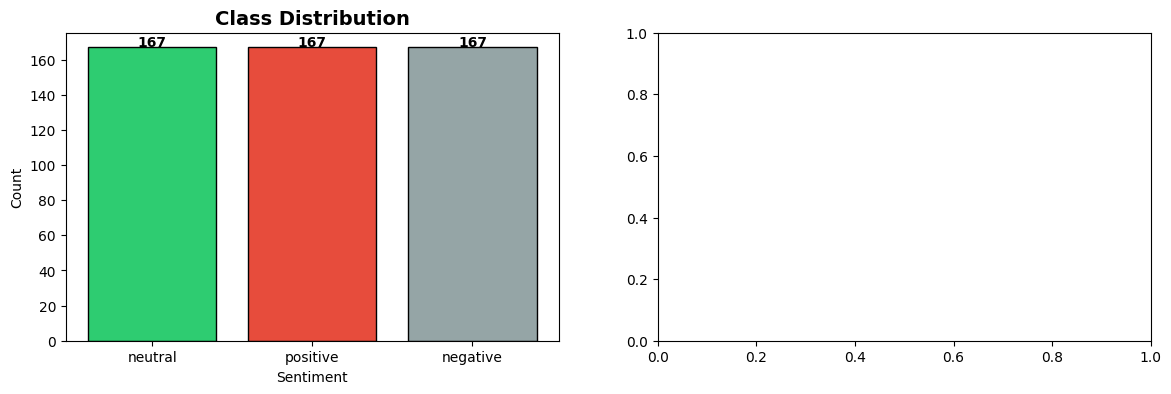

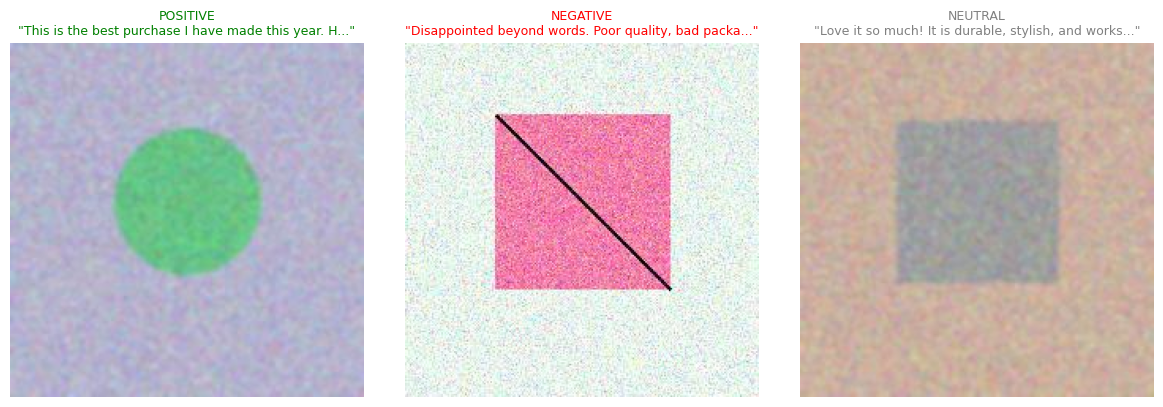

In [3]:
# Show class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
counts = df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=['#2ecc71','#e74c3c','#95a5a6'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment'); axes[0].set_ylabel('Count')
for i,(k,v) in enumerate(counts.items()):
    axes[0].text(i, v+0.5, str(v), ha='center', fontweight='bold')

# Sample images per class
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
for ax, sentiment in zip(axes2, ['positive','negative','neutral']):
    sample = df[df['sentiment']==sentiment].iloc[0]
    img    = Image.open(os.path.join(OUTPUT_DIR, sample['image_path']))
    ax.imshow(img)
    ax.set_title(f"{sentiment.upper()}\n\"{sample['review'][:50]}...\"",
                 fontsize=9, color={'positive':'green','negative':'red','neutral':'gray'}[sentiment])
    ax.axis('off')

plt.tight_layout()
plt.show()

## 🔤 Step 4 — Build Vocabulary from Reviews

In [4]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# Build vocabulary
all_tokens = [tok for review in df['review'] for tok in tokenize(review)]
freq        = Counter(all_tokens)
vocab       = ['<PAD>', '<UNK>'] + [w for w,c in freq.most_common() if c >= 1]
word2idx    = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE  = len(vocab)
MAX_LEN     = 30   # max tokens per review

print(f'Vocabulary size : {VOCAB_SIZE}')
print(f'Max review length: {MAX_LEN}')
print(f'Sample tokens   : {vocab[2:12]}')

def encode_review(text, max_len=MAX_LEN):
    tokens = tokenize(text)[:max_len]
    ids    = [word2idx.get(t, 1) for t in tokens]          # 1 = <UNK>
    ids   += [0] * (max_len - len(ids))                    # 0 = <PAD>
    return ids

print('\nEncoded sample review:', encode_review(df['review'].iloc[0]))

Vocabulary size : 231
Max review length: 30
Sample tokens   : ['it', 'and', 'the', 'product', 'quality', 'is', 'but', 'this', 'not', 'average']

Encoded sample review: [79, 2, 94, 46, 2, 7, 180, 181, 3, 19, 59, 37, 80, 22, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## 🗂️ Step 5 — Train / Val / Test Split & PyTorch Dataset

In [5]:
train_df, temp_df = train_test_split(df, test_size=0.3,  random_state=SEED, stratify=df['label'])
val_df,   test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label'])

print(f'Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}')

# Image transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

class SentimentDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        # Image
        img   = Image.open(os.path.join(self.img_dir, row['image_path'])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        # Text
        text  = torch.tensor(encode_review(row['review']), dtype=torch.long)
        label = torch.tensor(row['label'], dtype=torch.long)
        return img, text, label

BATCH = 16
train_ds = SentimentDataset(train_df, OUTPUT_DIR, train_transforms)
val_ds   = SentimentDataset(val_df,   OUTPUT_DIR, val_transforms)
test_ds  = SentimentDataset(test_df,  OUTPUT_DIR, val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH)
test_loader  = DataLoader(test_ds,  batch_size=BATCH)

print('DataLoaders ready ✅')

Train : 350 | Val : 75 | Test : 76
DataLoaders ready ✅


## 🏗️ Step 6 — Build the Multimodal Model

```
Image  → MobileNetV2 (pretrained CNN) → 512-d vector
                                                       → Concat → FC layers → Softmax
Text   → Embedding → BiLSTM           → 256-d vector
```

In [6]:
# ── CNN Branch ────────────────────────────────────────────────────────────────
class CNNBranch(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        # Freeze early layers, fine-tune last few
        for param in list(base.parameters())[:-20]:
            param.requires_grad = False
        self.features = base.features
        self.pool     = nn.AdaptiveAvgPool2d((1,1))
        self.fc       = nn.Sequential(
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, out_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.features(x)          # (B, 1280, 7, 7)
        x = self.pool(x)              # (B, 1280, 1, 1)
        x = x.view(x.size(0), -1)     # (B, 1280)
        return self.fc(x)             # (B, out_dim)


# ── LSTM Branch ───────────────────────────────────────────────────────────────
class LSTMBranch(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128, out_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                                  batch_first=True, bidirectional=True,
                                  dropout=0.3)
        self.fc        = nn.Sequential(
            nn.Linear(hidden_dim * 2, out_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x  = self.embedding(x)              # (B, seq, embed)
        _, (h, _) = self.lstm(x)            # h: (4, B, hidden)
        # Concat last forward & backward hidden states
        h  = torch.cat([h[-2], h[-1]], dim=1)  # (B, hidden*2)
        return self.fc(h)                   # (B, out_dim)


# ── Fusion Model ──────────────────────────────────────────────────────────────
class MultimodalSentimentModel(nn.Module):
    def __init__(self, vocab_size, num_classes=3):
        super().__init__()
        self.cnn_branch  = CNNBranch(out_dim=256)
        self.lstm_branch = LSTMBranch(vocab_size, out_dim=256)
        # Feed-Forward Fusion (Exercise 1)
        self.classifier  = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, img, text):
        img_feat  = self.cnn_branch(img)           # (B, 256)
        text_feat = self.lstm_branch(text)         # (B, 256)
        fused     = torch.cat([img_feat, text_feat], dim=1)  # (B, 512)
        return self.classifier(fused)              # (B, 3)


model = MultimodalSentimentModel(VOCAB_SIZE).to(DEVICE)
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(model)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 130MB/s]


Total parameters    : 3,850,179
Trainable parameters: 2,676,867
MultimodalSentimentModel(
  (cnn_branch): CNNBranch(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
     

## 🏋️ Step 7 — Train the Model

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, texts, labels in loader:
        imgs, texts, labels = imgs.to(DEVICE), texts.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs, texts)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, texts, labels in loader:
        imgs, texts, labels = imgs.to(DEVICE), texts.to(DEVICE), labels.to(DEVICE)
        outputs     = model(imgs, texts)
        loss        = criterion(outputs, labels)
        total_loss += loss.item()
        preds       = outputs.argmax(1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


EPOCHS = 10
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc = 0.0

print(f'{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}')
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader)
    vl_loss, vl_acc = eval_epoch(model, val_loader)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_model.pth')

    print(f'{epoch:>6} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>8.4f} | {vl_acc:>7.4f}')

print(f'\n✅ Best Validation Accuracy: {best_val_acc:.4f}')

 Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-------------------------------------------------------
     1 |     0.1439 |    0.9800 |   0.5806 |  0.9067
     2 |     0.3341 |    0.9429 |   0.0865 |  0.9733
     3 |     0.2339 |    0.9686 |   0.0335 |  0.9867
     4 |     0.1397 |    0.9771 |   0.0426 |  0.9867
     5 |     0.0742 |    0.9829 |   0.0338 |  0.9867
     6 |     0.0773 |    0.9829 |   0.0708 |  0.9867
     7 |     0.0228 |    0.9886 |   0.0601 |  0.9867
     8 |     0.0418 |    0.9886 |   0.0806 |  0.9867
     9 |     0.0511 |    0.9914 |   0.0081 |  1.0000
    10 |     0.0159 |    0.9971 |   0.0118 |  1.0000

✅ Best Validation Accuracy: 1.0000


## 📈 Step 8 — Plot Training Curves

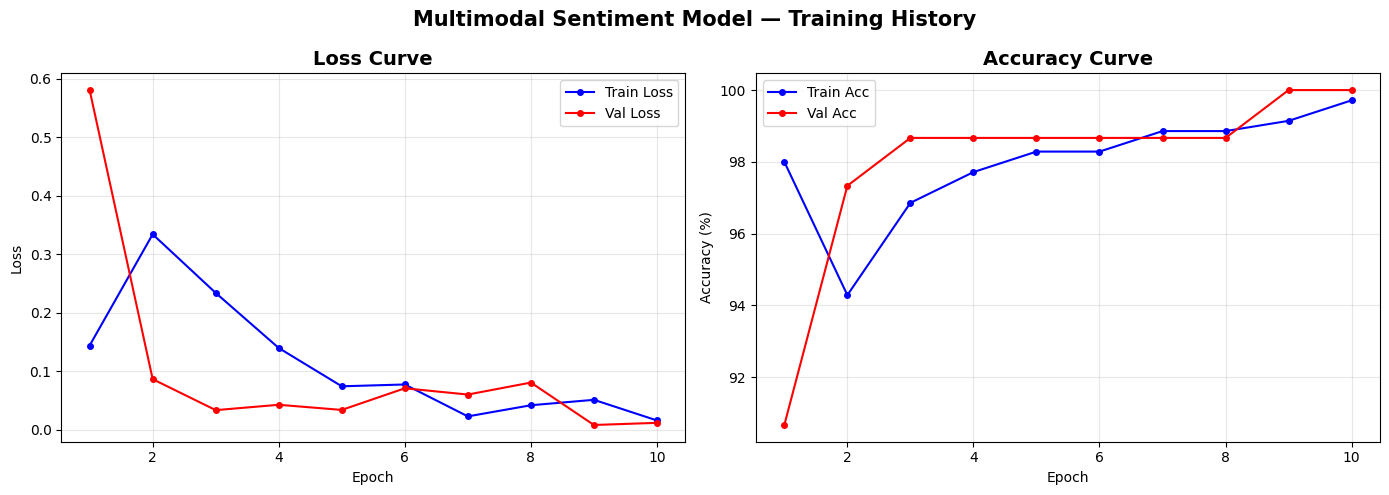

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=4)
axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Multimodal Sentiment Model — Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 🧪 Step 9 — Evaluate on Test Set

In [16]:
# Load best model
model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, texts, labels in test_loader:
        imgs, texts = imgs.to(DEVICE), texts.to(DEVICE)
        outputs     = model(imgs, texts)
        preds       = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

label_names = ['negative', 'neutral', 'positive']
print('=' * 50)
print('       CLASSIFICATION REPORT')
print('=' * 50)
print(classification_report(all_labels, all_preds, target_names=label_names))
print(f'Overall Test Accuracy: {accuracy_score(all_labels, all_preds):.4f}')

       CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        25
     neutral       0.96      1.00      0.98        25
    positive       1.00      0.96      0.98        26

    accuracy                           0.99        76
   macro avg       0.99      0.99      0.99        76
weighted avg       0.99      0.99      0.99        76

Overall Test Accuracy: 0.9868


## 🔥 Step 10 — Confusion Matrix

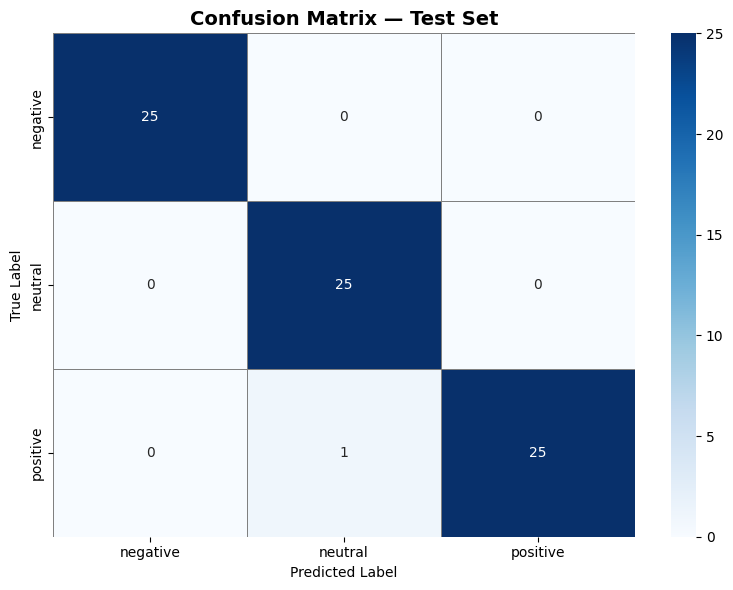

In [17]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='gray')
plt.title('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚖️ Step 11 — Ablation Study (Text-only vs Image-only vs Multimodal)

Training Text-only  model... Test Acc = 0.6053
Training Image-only model... Test Acc = 0.9605

Multimodal model   Test Acc = 0.9868


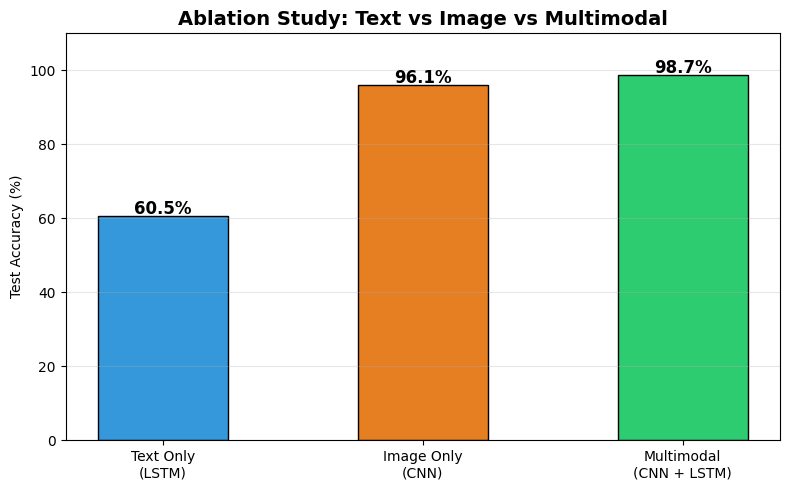

In [18]:
# ── Text-only model ───────────────────────────────────────────────────────────
class TextOnlyModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.lstm = LSTMBranch(vocab_size, out_dim=256)
        self.fc   = nn.Linear(256, 3)
    def forward(self, text):
        return self.fc(self.lstm(text))

# ── Image-only model ──────────────────────────────────────────────────────────
class ImageOnlyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CNNBranch(out_dim=256)
        self.fc  = nn.Linear(256, 3)
    def forward(self, img):
        return self.fc(self.cnn(img))

def quick_train(model, loader, epochs=8, lr=1e-3):
    opt = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    model.train()
    for _ in range(epochs):
        for batch in loader:
            imgs, texts, labels = batch
            imgs, texts, labels = imgs.to(DEVICE), texts.to(DEVICE), labels.to(DEVICE)
            opt.zero_grad()
            if isinstance(model, TextOnlyModel):
                out = model(texts)
            else:
                out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            opt.step()

def quick_eval(model, loader):
    model.eval(); correct = total = 0
    with torch.no_grad():
        for imgs, texts, labels in loader:
            imgs, texts, labels = imgs.to(DEVICE), texts.to(DEVICE), labels.to(DEVICE)
            if isinstance(model, TextOnlyModel):
                out = model(texts)
            else:
                out = model(imgs)
            correct += (out.argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total

print('Training Text-only  model...', end=' ')
text_model = TextOnlyModel(VOCAB_SIZE).to(DEVICE)
quick_train(text_model, train_loader)
text_acc = quick_eval(text_model, test_loader)
print(f'Test Acc = {text_acc:.4f}')

print('Training Image-only model...', end=' ')
img_model = ImageOnlyModel().to(DEVICE)
quick_train(img_model, train_loader)
img_acc = quick_eval(img_model, test_loader)
print(f'Test Acc = {img_acc:.4f}')

multi_acc = accuracy_score(all_labels, all_preds)
print(f'\nMultimodal model   Test Acc = {multi_acc:.4f}')

# ── Bar chart comparison ──────────────────────────────────────────────────────
models_compared = ['Text Only\n(LSTM)', 'Image Only\n(CNN)', 'Multimodal\n(CNN + LSTM)']
accs            = [text_acc*100, img_acc*100, multi_acc*100]
colors          = ['#3498db', '#e67e22', '#2ecc71']

plt.figure(figsize=(8, 5))
bars = plt.bar(models_compared, accs, color=colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.5,
             f'{acc:.1f}%', ha='center', fontweight='bold', fontsize=12)
plt.title('Ablation Study: Text vs Image vs Multimodal', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔮 Step 12 — Predict on New Samples

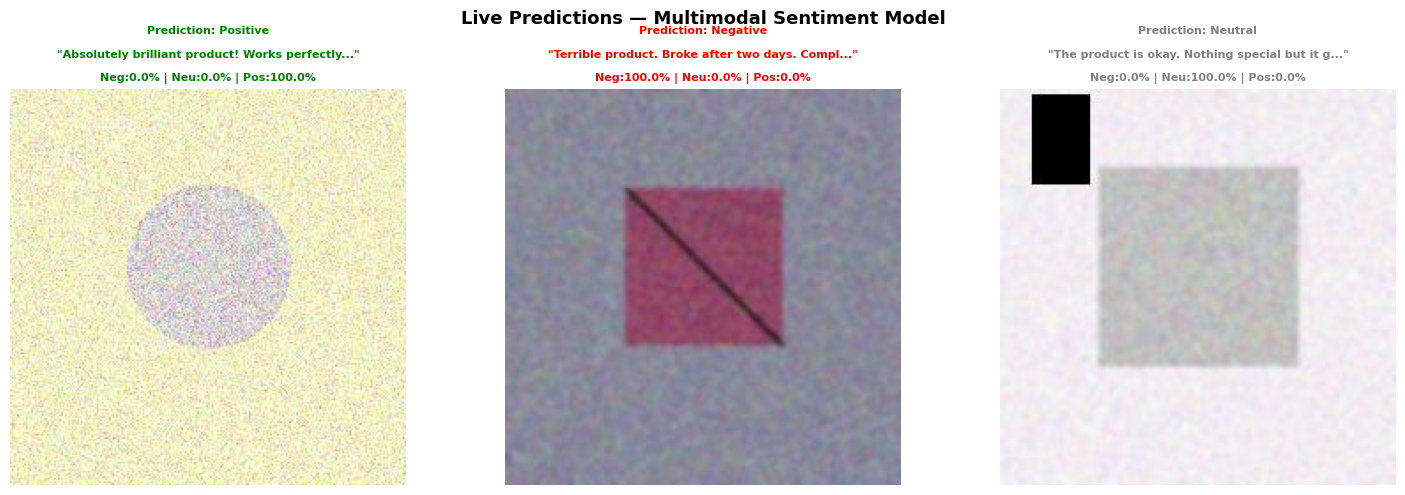

In [20]:
def predict_sentiment(image_path, review_text, model=model):
    """Predict sentiment given an image path and review text."""
    model.eval()
    # Preprocess image
    img   = Image.open(image_path).convert('RGB')
    img_t = val_transforms(img).unsqueeze(0).to(DEVICE)
    # Preprocess text
    txt_t = torch.tensor([encode_review(review_text)], dtype=torch.long).to(DEVICE)
    # Predict
    with torch.no_grad():
        logits = model(img_t, txt_t)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
    label_names = ['Negative', 'Neutral', 'Positive']
    pred_label  = label_names[probs.argmax()]
    return pred_label, {l: float(f'{p*100:.1f}') for l,p in zip(label_names, probs)}

# ── Test on a few samples ─────────────────────────────────────────────────────
test_cases = [
    ("dataset/images/positive_36_9432.jpg",
     "Absolutely brilliant product! Works perfectly and exceeded expectations."),
    ("dataset/images/negative_0_1499.jpg",
     "Terrible product. Broke after two days. Complete waste of money."),
    ("dataset/images/neutral_12_1310.jpg",
     "The product is okay. Nothing special but it gets the job done."),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (img_path, review) in zip(axes, test_cases):
    pred, probs = predict_sentiment(img_path, review)
    img         = Image.open(img_path)
    color       = {'Positive':'green','Negative':'red','Neutral':'gray'}[pred]
    ax.imshow(img)
    title = f'Prediction: {pred}\n\n"{review[:45]}..."\n\nNeg:{probs["Negative"]}% | Neu:{probs["Neutral"]}% | Pos:{probs["Positive"]}%'
    ax.set_title(title, fontsize=8, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Live Predictions — Multimodal Sentiment Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Step 13 — Final Summary

In [21]:
print('=' * 55)
print('         MULTIMODAL SENTIMENT ANALYSIS')
print('               FINAL SUMMARY')
print('=' * 55)
print(f'Dataset            : 501 samples (~167 per class)')
print(f'Train/Val/Test     : {len(train_df)}/{len(val_df)}/{len(test_df)}')
print(f'Vocabulary Size    : {VOCAB_SIZE}')
print(f'Max Review Length  : {MAX_LEN} tokens')
print(f'Batch Size         : {BATCH}')
print(f'Epochs Trained     : {EPOCHS}')
print('-' * 55)
print(f'Text-only Accuracy : {text_acc*100:.2f}%')
print(f'Image-only Accuracy: {img_acc*100:.2f}%')
print(f'Multimodal Accuracy: {multi_acc*100:.2f}%  ← BEST')
print('-' * 55)
print('Architecture:')
print('  CNN  : MobileNetV2 (pretrained) → 256-d')
print('  LSTM : BiLSTM (2 layers)        → 256-d')
print('  Fusion: Concat → FC(512→256→128→3) → Softmax')
print('=' * 55)

         MULTIMODAL SENTIMENT ANALYSIS
               FINAL SUMMARY
Dataset            : 501 samples (~167 per class)
Train/Val/Test     : 350/75/76
Vocabulary Size    : 231
Max Review Length  : 30 tokens
Batch Size         : 16
Epochs Trained     : 10
-------------------------------------------------------
Text-only Accuracy : 60.53%
Image-only Accuracy: 96.05%
Multimodal Accuracy: 98.68%  ← BEST
-------------------------------------------------------
Architecture:
  CNN  : MobileNetV2 (pretrained) → 256-d
  LSTM : BiLSTM (2 layers)        → 256-d
  Fusion: Concat → FC(512→256→128→3) → Softmax
